In [15]:
#extract values from dataframe

import pandas as pd
fname_base = 'DyHANE/'

df = pd.read_csv(fname_base+'params_scores_all.csv')

#ignoriamo il weigth_decay per evitare troppe configurazioni
#prendiamo i valori con wd = 0.0001
#come score usiamo F1_weighted

def drop_column(df, col_name):
    return df.drop(col_name, axis=1)

def extract_params(params):
    params = params[1:-1]
    params_list = params.split(', ')
    return int(params_list[0]), float(params_list[1]), float(params_list[2]), float(params_list[3])

def extract_score(f1_measure):
    return float(f1_measure.split('±')[0])


#drop columns
df = drop_column(df, 'F1_micro')
df = drop_column(df, 'F1_macro')
df = drop_column(df, 'ROC-AUC')
df = drop_column(df, 'score')

#extract params
df[['B_size', 'dropout', 'lr', 'L2']] = df['Params'].apply(lambda x: pd.Series(extract_params(x)))
df['B_size'] = df['B_size'].astype(int)
df = drop_column(df, 'Params')

#extract f1-weigthed score
df['score_f1-w'] = df.apply(lambda x: extract_score(x['F1_weighted']), axis=1)
df = drop_column(df, 'F1_weighted')

#sort by f1-weighted score and drop duplicates keeping the first
#df = df.sort_values(by='score_f1-w', ascending=False).drop_duplicates(subset=['B_size', 'dropout', 'lr'])
#alternative: keep the rows in correspondance to wd = 0.0001
df = df[df['L2'] == 0.0001]
df = drop_column(df, 'L2')

print(df.shape)
print(df.head(5))

print(df['B_size'].drop_duplicates().tolist())
print(df['dropout'].drop_duplicates().tolist())
print(df['lr'].drop_duplicates().tolist())


(100, 4)
   B_size  dropout     lr  score_f1-w
0    2048      0.3  0.010      0.6823
1    2048      0.3  0.005      0.6793
2    2048      0.4  0.010      0.6813
3    2048      0.4  0.005      0.6775
5    1024      0.3  0.005      0.6732
[2048, 1024, 768, 512, 256]
[0.3, 0.4, 0.5, 0.6, 0.7]
[0.01, 0.005, 0.001, 0.05]


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

#accrocco
def accrocco(B_size):
    return 1280 if B_size == 2048 else B_size
df['B_size_dummy'] = df.apply(lambda x: accrocco(x['B_size']), axis=1)
drop_column(df,'B_size')
df.rename(columns={'B_size_dummy':'B_size', 'dropout':'Dropout', 'lr':'Learning_rate', 'score_f1-w':'F1-weighted'}, inplace=True)

# columns names: B_size  dropout     lr  score_f1-w
#colors = ['r', 'g', 'b', 'c', 'm']  # Define colors for dr values
#symbols = ['o', 's', '^', 'D']      # Define symbols for lr values

# Creating a dictionary to map symbols to white symbols for lr
symbol_mapping = {0.001: 'o', 0.005: 's', 0.01: 'D', 0.05:'^'}

# Creating a dictionary to map colors to unique symbols for dr
color_mapping = {0.3: 'x', 0.4: '+', 0.5: '^', 0.6: '>', 0.7: '<'}

# Create a scatter plot
sns.scatterplot(data=df, x='B_size', y='F1-weighted', hue='Dropout', style='Learning_rate', palette='colorblind', markers=symbol_mapping, style_order=[0.001, 0.005, 0.01, 0.05], hue_order=[0.3, 0.4, 0.5, 0.6, 0.7])

#accrocco
B_size_values = df['B_size'].tolist()
B_size_values_pos = [x if x <= 1024 else 1280 for x in B_size_values]
B_size_values_pos_unique = sorted(list(set(B_size_values_pos)))
# Calculate positions for vertical lines to separate groups
num_bsize = len(B_size_values_pos_unique)
line_positions = [(B_size_values_pos_unique[i] + B_size_values_pos_unique[i+1]) / 2 for i in range(num_bsize - 1)]
#line_positions.append(1408)
#line_positions.append(1700)

# Adding vertical lines separating the B_size
'''
for b_size in [512, 1024, 2048]:
    plt.axvline(x=b_size, color='gray', linestyle='--', linewidth=0.5)
'''
for pos in line_positions: #[:-1]
    plt.axvline(x=pos, color='k', linestyle='--', linewidth=0.5)
#plt.axvline(x=line_positions[-1], color='w', linestyle='--', linewidth=0.5)
#plt.axvline(x=line_positions[-2], color='w', linestyle='--', linewidth=0.5)

# Adjusting x-axis ticks to ensure uniform distribution
plt.xticks([256, 512, 768, 1024, 1280], ['256', '512', '768', '1024', '2048'])
#plt.xticks([256, 512, 768, 1024, 2048], labels=['256', '512', '768', '1024', '2048'])
#plt.xticks(B_size_values_pos, B_size_values)  # ticks, labels
# Customizing x-axis ticks to ensure uniform distribution
#plt.gca().xaxis.set_major_locator(MultipleLocator(256))
#plt.gca().set_xticklabels(['256', '512', '768', '1024', '1280', '1536', '1792', '2048'])


# Adding legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) #title='Legend', 
#plt.legend(loc='upper right')

# Display the plot
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [5]:
#tenendo anche weigth_decay:

df_wd = pd.read_csv(fname_base+'params_scores_all.csv')

#ignoriamo il weigth_decay per evitare troppe configurazioni
#prendiamo i valori con wd = 0.0001
#come score usiamo F1_weighted

def drop_column(df, col_name):
    return df.drop(col_name, axis=1)

def extract_params(params):
    params = params[1:-1]
    params_list = params.split(', ')
    return int(params_list[0]), float(params_list[1]), float(params_list[2]), float(params_list[3])

def extract_score(f1_measure):
    return float(f1_measure.split('±')[0])


#drop columns
df_wd = drop_column(df_wd, 'F1_micro')
df_wd = drop_column(df_wd, 'F1_macro')
df_wd = drop_column(df_wd, 'ROC-AUC')
df_wd = drop_column(df_wd, 'score')

#extract params
df_wd[['B_size', 'dropout', 'lr', 'L2']] = df_wd['Params'].apply(lambda x: pd.Series(extract_params(x)))
df_wd['B_size'] = df_wd['B_size'].astype(int)
df_wd = drop_column(df_wd, 'Params')

#extract f1-weigthed score
df_wd['score_f1-w'] = df_wd.apply(lambda x: extract_score(x['F1_weighted']), axis=1)
df_wd = drop_column(df_wd, 'F1_weighted')

print(df_wd.shape)



(400, 5)


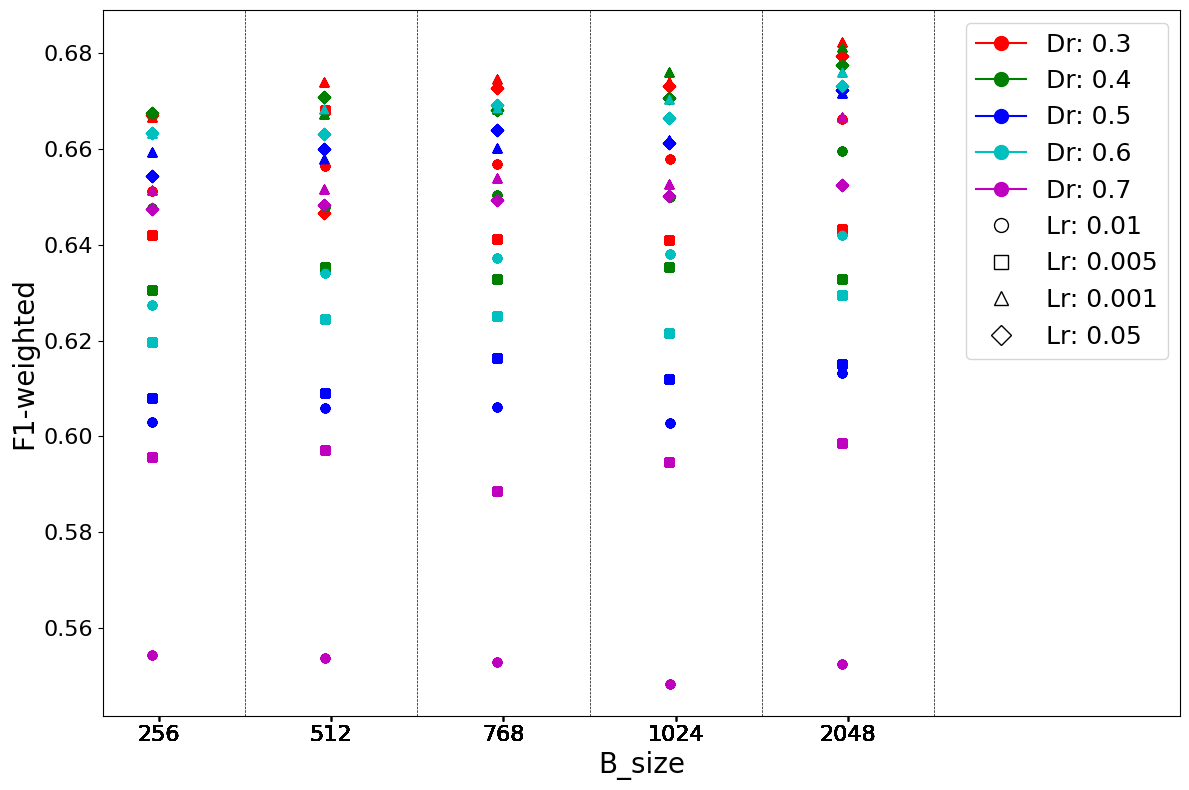

In [89]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools
import random


B_size_values = df['B_size'].tolist()
dr_values = df['dropout'].tolist()
lr_values = df['lr'].tolist()

scores = {}
for index, row in df.iterrows():
    key = (row['B_size'], row['dropout'], row['lr'])
    value = row['score_f1-w']
    scores[key] = value

# User-defined colors and symbols
colors = ['r', 'g', 'b', 'c', 'm']  # Define colors for dr values
symbols = ['o', 's', '^', 'D']      # Define symbols for lr values


# Plotting
plt.figure(figsize=(12, 8)) #8, 6

#accrocco
B_size_values_pos = [x if x <= 1024 else 1280 for x in B_size_values]
B_size_values_pos_unique = sorted(list(set(B_size_values_pos)))


# Calculate positions for vertical lines to separate groups
#num_bsize = len(B_size_values)
#line_positions = [(B_size_values_pos[i] + B_size_values_pos[i+1]) / 2 for i in range(num_bsize - 1)]
num_bsize = len(B_size_values_pos_unique)
line_positions = [(B_size_values_pos_unique[i] + B_size_values_pos_unique[i+1]) / 2 for i in range(num_bsize - 1)]
line_positions.append(1408)
line_positions.append(1700)

for i, B_size in enumerate(B_size_values):

    #accrocco
    B_size_dummy = 1280 if B_size==2048 else B_size

    scores_for_B_size = [(dr, lr, score) for (b, dr, lr), score in scores.items() if b == B_size]
    drs = [dr for (dr, lr, score) in scores_for_B_size]
    lrs = [lr for (dr, lr, score) in scores_for_B_size]
    scores_val = [score for (dr, lr, score) in scores_for_B_size]
    
    # Offset for visual separation
    offset = 0.2
    x = [B_size_dummy + offset * (i - (len(B_size_values)-1)/2) for i in range(len(drs))]
    
    for j, dr in enumerate(set(drs)):
        dr_indices = [idx for idx, val in enumerate(drs) if val == dr]
        dr_scores = [scores_val[idx] for idx in dr_indices]
        lrs_dr = [lrs[idx] for idx in dr_indices]
        symbols_iter = iter(symbols)
        for k, lr in enumerate(set(lrs_dr)):
            lr_indices = [idx for idx, val in enumerate(lrs_dr) if val == lr]
            lr_scores = [dr_scores[idx] for idx in lr_indices]
            plt.scatter([x[idx] for idx in lr_indices], lr_scores, color=colors[j], marker=next(symbols_iter))

# Add vertical lines to separate groups

for pos in line_positions[:-1]:
    plt.axvline(x=pos, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=line_positions[-1], color='w', linestyle='--', linewidth=0.5)

    
# Create custom legend
legend_elements = []

# Track added dropout/lr values
added_dropout = set()
added_lr = set()

# Cycle through colors/symbols
#color_cycle = itertools.cycle(plt.cm.tab10.colors)
#color_cycle = ['#FF5733', '#33FF57', '#3366FF', '#FF33DD', '#FFFF33']
color_cycle = itertools.cycle(colors)
symbol_cycle = itertools.cycle(symbols)

# Add Dropout colors to legend for distinct dr_values
for dr in dr_values:
    if dr not in added_dropout:
        color = next(color_cycle)
        legend_elements.append(Line2D([0], [0], marker='o', color=color, label=f'Dr: {dr}', markersize=10))
        added_dropout.add(dr)



# Add Learning rate symbols to legend for distinct lr_values
for lr in lr_values:
    if lr not in added_lr:
        symbol = next(symbol_cycle)
        legend_elements.append(Line2D([0], [0], marker=symbol, color='w', markeredgecolor='k', label=f'Lr: {lr}', markersize=10))
        added_lr.add(lr)
# Remove duplicates from legend elements
#legend_elements = [elem for elem in legend_elements if elem not in legend_elements]

unique_legend_elements = []
for element in legend_elements:
    if element not in unique_legend_elements:
        unique_legend_elements.append(element)


# Position the legend
plt.legend(handles=legend_elements, loc='upper right', ncol=1, prop={'size': 18}) #bbox_to_anchor=(1.05, 1), title="Legend"

plt.xlabel('B_size', fontsize=20)
plt.ylabel('F1-weighted', fontsize=20)
#plt.title('Scores for different B_size, dropout and learning_rate combinations', fontsize=18)
#plt.xticks(B_size_values)
plt.xticks(B_size_values_pos, B_size_values)  # ticks, labels
plt.tick_params(axis='x', labelsize=16)  
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig(fname_base+'Scatterplot.png')
plt.show()

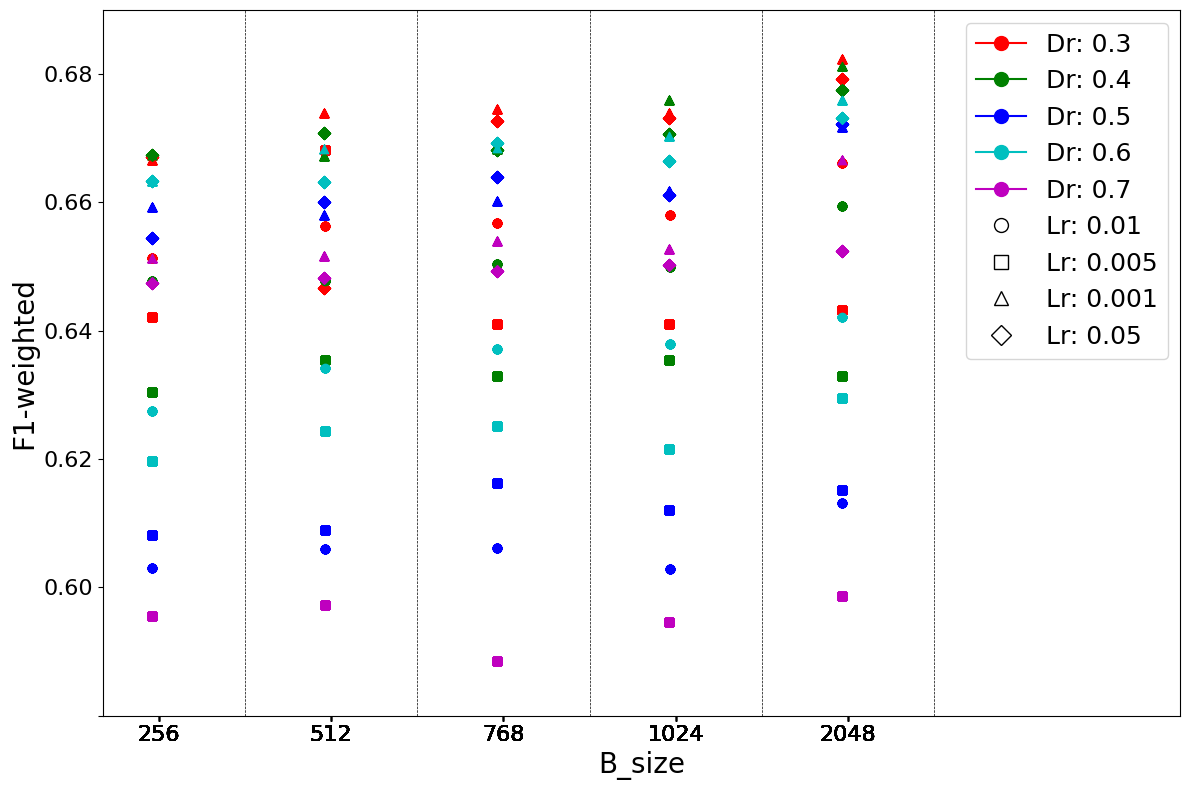

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import itertools
import random


B_size_values = df['B_size'].tolist()
dr_values = df['dropout'].tolist()
lr_values = df['lr'].tolist()

scores = {}
for index, row in df.iterrows():
    key = (row['B_size'], row['dropout'], row['lr'])
    value = row['score_f1-w']
    scores[key] = value

# User-defined colors and symbols
colors = ['r', 'g', 'b', 'c', 'm']  # Define colors for dr values
symbols = ['o', 's', '^', 'D']      # Define symbols for lr values


# Plotting
plt.figure(figsize=(12, 8)) #8, 6

#accrocco
B_size_values_pos = [x if x <= 1024 else 1280 for x in B_size_values]
B_size_values_pos_unique = sorted(list(set(B_size_values_pos)))


# Calculate positions for vertical lines to separate groups
#num_bsize = len(B_size_values)
#line_positions = [(B_size_values_pos[i] + B_size_values_pos[i+1]) / 2 for i in range(num_bsize - 1)]
num_bsize = len(B_size_values_pos_unique)
line_positions = [(B_size_values_pos_unique[i] + B_size_values_pos_unique[i+1]) / 2 for i in range(num_bsize - 1)]
line_positions.append(1408)
line_positions.append(1700)

for i, B_size in enumerate(B_size_values):

    #accrocco
    B_size_dummy = 1280 if B_size==2048 else B_size

    scores_for_B_size = [(dr, lr, score) for (b, dr, lr), score in scores.items() if b == B_size]
    drs = [dr for (dr, lr, score) in scores_for_B_size]
    lrs = [lr for (dr, lr, score) in scores_for_B_size]
    scores_val = [score for (dr, lr, score) in scores_for_B_size]
    
    # Offset for visual separation
    offset = 0.2
    x = [B_size_dummy + offset * (i - (len(B_size_values)-1)/2) for i in range(len(drs))]
    
    for j, dr in enumerate(set(drs)):
        dr_indices = [idx for idx, val in enumerate(drs) if val == dr]
        dr_scores = [scores_val[idx] for idx in dr_indices]
        lrs_dr = [lrs[idx] for idx in dr_indices]
        symbols_iter = iter(symbols)
        for k, lr in enumerate(set(lrs_dr)):
            lr_indices = [idx for idx, val in enumerate(lrs_dr) if val == lr]
            lr_scores = [dr_scores[idx] for idx in lr_indices]
            plt.scatter([x[idx] for idx in lr_indices], lr_scores, color=colors[j], marker=next(symbols_iter))

# Add vertical lines to separate groups

for pos in line_positions[:-1]:
    plt.axvline(x=pos, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=line_positions[-1], color='w', linestyle='--', linewidth=0.5)

    
# Create custom legend
legend_elements = []

# Track added dropout/lr values
added_dropout = set()
added_lr = set()

# Cycle through colors/symbols
#color_cycle = itertools.cycle(plt.cm.tab10.colors)
#color_cycle = ['#FF5733', '#33FF57', '#3366FF', '#FF33DD', '#FFFF33']
color_cycle = itertools.cycle(colors)
symbol_cycle = itertools.cycle(symbols)

# Add Dropout colors to legend for distinct dr_values
for dr in dr_values:
    if dr not in added_dropout:
        color = next(color_cycle)
        legend_elements.append(Line2D([0], [0], marker='o', color=color, label=f'Dr: {dr}', markersize=10))
        added_dropout.add(dr)



# Add Learning rate symbols to legend for distinct lr_values
for lr in lr_values:
    if lr not in added_lr:
        symbol = next(symbol_cycle)
        legend_elements.append(Line2D([0], [0], marker=symbol, color='w', markeredgecolor='k', label=f'Lr: {lr}', markersize=10))
        added_lr.add(lr)
# Remove duplicates from legend elements
#legend_elements = [elem for elem in legend_elements if elem not in legend_elements]

unique_legend_elements = []
for element in legend_elements:
    if element not in unique_legend_elements:
        unique_legend_elements.append(element)


# Position the legend
plt.legend(handles=legend_elements, loc='upper right', ncol=1, prop={'size': 18}) #bbox_to_anchor=(1.05, 1), title="Legend"

plt.xlabel('B_size', fontsize=20)
plt.ylabel('F1-weighted', fontsize=20)
#plt.title('Scores for different B_size, dropout and learning_rate combinations', fontsize=18)
#plt.xticks(B_size_values)
plt.xticks(B_size_values_pos, B_size_values)  # ticks, labels
plt.ylim(0.58, 0.69)
# Hide the tick label corresponding to the first value
plt.gca().get_yticklabels()[0].set_visible(False)
plt.gca().get_yticklabels()[-1].set_visible(False)
plt.tick_params(axis='x', labelsize=16)  
plt.tick_params(axis='y', labelsize=16)
plt.tight_layout()
plt.savefig(fname_base+'Scatterplot_sub.png')
plt.show()

In [6]:
pd.set_option('mode.chained_assignment', None)

#top configuration
best_B_size = 768
best_dropout = 0.3
best_learning_rate = 0.001
best_L2 = 0.0001

#changing B_size
df_B_size = df[(df['dropout'] == best_dropout) & (df['lr'] == best_learning_rate)]
df_B_size['L2'] = 0.0001
df_B_size = df_B_size.sort_values(by='B_size')
#df_B_size

#changing dropout
df_dropout = df[(df['B_size'] == best_B_size) & (df['lr'] == best_learning_rate)]
df_dropout['L2'] = 0.0001
df_dropout = df_dropout.sort_values(by='dropout')
#df_dropout

#changing learning_rate
df_lr = df[(df['B_size'] == best_B_size) & (df['dropout'] == best_dropout)]
df_lr['L2'] = 0.0001
df_lr = df_lr.sort_values(by='lr')
#df_lr

#changing weigth_decay
df_L2 = df_wd[(df_wd['B_size'] == best_B_size) & (df_wd['dropout'] == best_dropout) & (df_wd['lr'] == best_learning_rate)]
df_L2 = df_L2.sort_values(by='L2')
#df_L2


def build_dict(df, col_fixed1, col_fixed2, col_fixed3, col_changing):
    
    scores = {}
    for index, row in df.iterrows():
        key = (row[col_fixed1], row[col_fixed2], row[col_fixed3], row[col_changing])
        value = row['score_f1-w']
        scores[key] = value

    return scores

scores_B_size = build_dict(df_B_size, 'dropout', 'lr', 'L2', 'B_size')
print(scores_B_size)
print('####################')
scores_dropout = build_dict(df_dropout, 'B_size', 'lr', 'L2', 'dropout')
print(scores_dropout)
print('####################')
scores_lr = build_dict(df_lr, 'B_size', 'dropout', 'L2', 'lr')
print(scores_lr)
print('####################')
scores_L2 = build_dict(df_L2, 'B_size', 'dropout', 'lr', 'L2')
print(scores_L2)


{(0.3, 0.001, 0.0001, 256.0): 0.6421, (0.3, 0.001, 0.0001, 512.0): 0.6466, (0.3, 0.001, 0.0001, 768.0): 0.6411, (0.3, 0.001, 0.0001, 1024.0): 0.641, (0.3, 0.001, 0.0001, 2048.0): 0.6432}
####################
{(768.0, 0.001, 0.0001, 0.3): 0.6411, (768.0, 0.001, 0.0001, 0.4): 0.6329, (768.0, 0.001, 0.0001, 0.5): 0.6252, (768.0, 0.001, 0.0001, 0.6): 0.6163, (768.0, 0.001, 0.0001, 0.7): 0.5886}
####################
{(768.0, 0.3, 0.0001, 0.001): 0.6411, (768.0, 0.3, 0.0001, 0.005): 0.6727, (768.0, 0.3, 0.0001, 0.01): 0.6746, (768.0, 0.3, 0.0001, 0.05): 0.6568}
####################
{(768.0, 0.3, 0.001, 0.0001): 0.6411, (768.0, 0.3, 0.001, 0.0005): 0.6321, (768.0, 0.3, 0.001, 0.001): 0.6274, (768.0, 0.3, 0.001, 0.005): 0.5614}


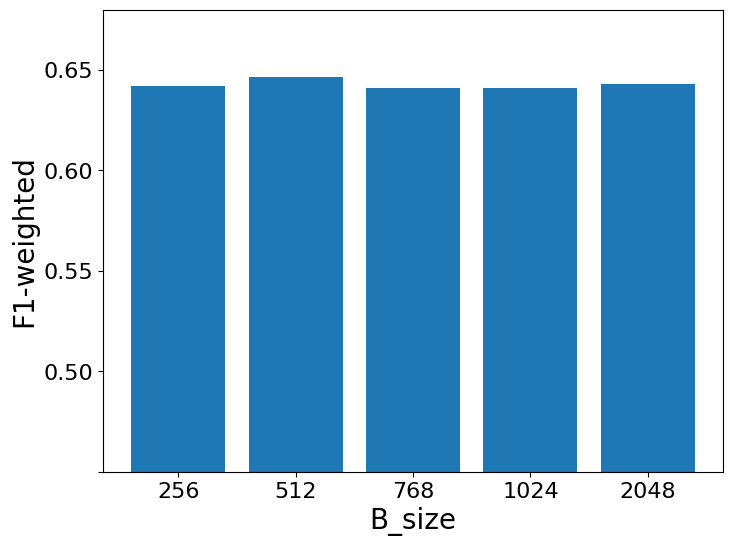

In [13]:
import matplotlib.pyplot as plt

hyperparameters_scores = scores_B_size

## Extract hyperparameters and scores
hyperparameters = [int(hp[-1]) for hp in hyperparameters_scores.keys()]
scores = list(hyperparameters_scores.values())

# Define colors for each bar
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Plotting
plt.figure(figsize=(8, 6))  # Adjust figure size
plt.bar(range(len(hyperparameters)), scores) #olor=colors
plt.xlabel('B_size', fontsize=20)
plt.ylabel('F1-weighted', fontsize=20)
#plt.title('Fixed (hyper)parameters: dr:0.3, lr:0.01, wd:0.0001', fontsize=20)
plt.xticks(range(len(hyperparameters)), hyperparameters)  # Set x-axis ticks
plt.ylim(0.45, 0.68)
# Hide the tick label corresponding to the first value
plt.gca().get_yticklabels()[0].set_visible(False)
plt.gca().get_yticklabels()[-1].set_visible(False)
plt.tick_params(axis='x', labelsize=16)  
plt.tick_params(axis='y', labelsize=16)
#plt.legend(['Fixed (hyper)parameters: dr: 0.3, lr: 0.01, wd: 0.0001'])
# Save the image
plt.savefig(fname_base+'B_size.png')

plt.show()

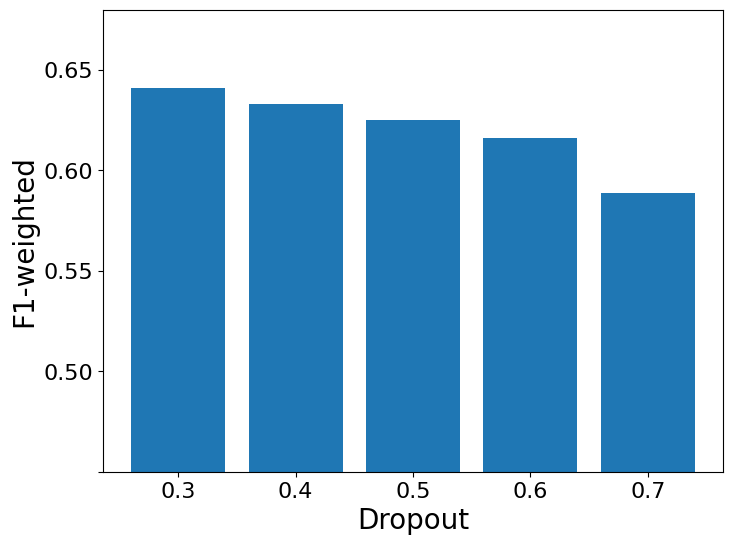

In [12]:
import matplotlib.pyplot as plt

hyperparameters_scores = scores_dropout

## Extract hyperparameters and scores
hyperparameters = [hp[-1] for hp in hyperparameters_scores.keys()]
scores = list(hyperparameters_scores.values())

# Define colors for each bar
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Plotting
plt.figure(figsize=(8, 6))  # Adjust figure size
plt.bar(range(len(hyperparameters)), scores) #olor=colors
plt.xlabel('Dropout', fontsize=20)
plt.ylabel('F1-weighted', fontsize=20)
#plt.title('Fixed (hyper)parameters: B_size:768, lr:0.01, wd:0.0001', fontsize=20)
plt.xticks(range(len(hyperparameters)), hyperparameters)  # Set x-axis ticks
plt.ylim(0.45, 0.68)
# Hide the tick label corresponding to the first value
plt.gca().get_yticklabels()[0].set_visible(False)
plt.tick_params(axis='x', labelsize=16)  
plt.tick_params(axis='y', labelsize=16)
#plt.legend(['Fixed (hyper)parameters: dr: 0.3, lr: 0.01, wd: 0.0001'])
# Save the image
plt.savefig(fname_base+'Dropout.png')

plt.show()

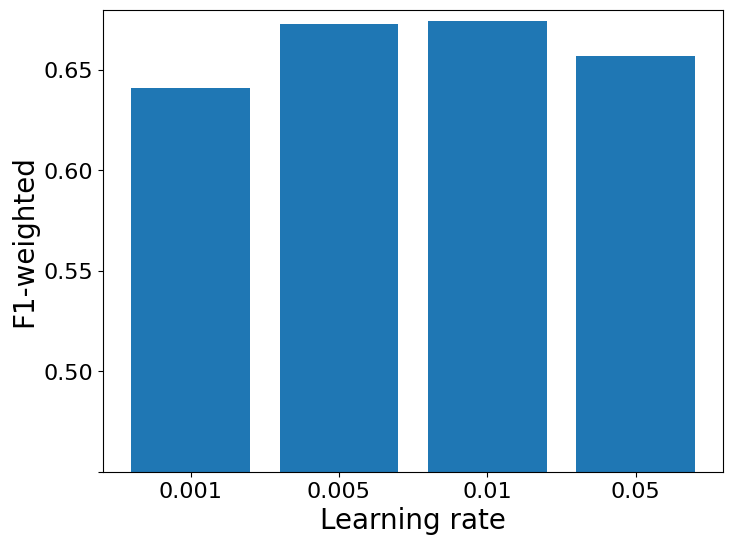

In [10]:
import matplotlib.pyplot as plt

hyperparameters_scores = scores_lr

## Extract hyperparameters and scores
hyperparameters = [hp[-1] for hp in hyperparameters_scores.keys()]
scores = list(hyperparameters_scores.values())

# Define colors for each bar
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Plotting
plt.figure(figsize=(8, 6))  # Adjust figure size
plt.bar(range(len(hyperparameters)), scores) #olor=colors
plt.xlabel('Learning rate', fontsize=20)
plt.ylabel('F1-weighted', fontsize=20)
#plt.title('Fixed (hyper)parameters: B_size:768, dr:0.3, wd:0.0001', fontsize=20)
plt.xticks(range(len(hyperparameters)), hyperparameters)  # Set x-axis ticks
plt.ylim(0.45, 0.68)
# Hide the tick label corresponding to the first value
plt.gca().get_yticklabels()[0].set_visible(False)
#plt.legend(['Fixed (hyper)parameters: dr: 0.3, lr: 0.01, wd: 0.0001'])
plt.tick_params(axis='x', labelsize=16)  
plt.tick_params(axis='y', labelsize=16)
# Save the image
plt.savefig(fname_base+'Learning_rate.png')

plt.show()

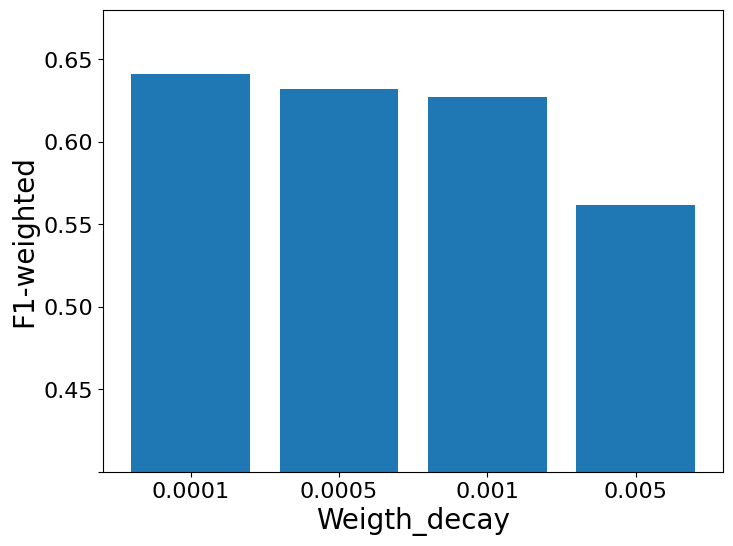

In [11]:
import matplotlib.pyplot as plt

hyperparameters_scores = scores_L2

## Extract hyperparameters and scores
hyperparameters = [hp[-1] for hp in hyperparameters_scores.keys()]
scores = list(hyperparameters_scores.values())

# Define colors for each bar
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Plotting
plt.figure(figsize=(8, 6))  # Adjust figure size
plt.bar(range(len(hyperparameters)), scores) #olor=colors
plt.xlabel('Weigth_decay', fontsize=20)
plt.ylabel('F1-weighted', fontsize=20)
#plt.title('Fixed (hyper)parameters: B_size:768, dr:0.3, lr:0.01', fontsize=20)
plt.xticks(range(len(hyperparameters)), hyperparameters)  # Set x-axis ticks
plt.ylim(0.4, 0.68)
# Hide the tick label corresponding to the first value
plt.gca().get_yticklabels()[0].set_visible(False)
plt.tick_params(axis='x', labelsize=16)  
plt.tick_params(axis='y', labelsize=16)
#plt.legend(['Fixed (hyper)parameters: dr: 0.3, lr: 0.01, wd: 0.0001'])
# Save the image
plt.savefig(fname_base+'L2.png')

plt.show()